# Flipkart Phones Data Cleaning & EDA

This notebook includes:

- Data Loading
- Data Cleaning
- Handling Missing Values
- Duplicate Removal
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Visualizations



In [8]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('Flipkart_phones.csv')

# Display First 5 Rows
df.head()


,Product_name,Price,Rating,No_of_ratings,No_of_reviews,Brand,Processor,RAM,ROM,Battery,Display_Size,Camera
0,"IQOO Z11x 5G (Prismatic Green, 128 GB)",21659.0,4.4,464,40,IQOO,NaN,6 GB,128 GB,7200 mAh,6.7 inch,50MP Rear Camera
1,MOTOROLA Edge 60 Fusion 5G (PANTONE Slipstream...,22999.0,4.4,119085,7005,MOTOROLA,Dimensity 7400,8 GB,128 GB,5500 mAh,6.67 inch,50MP + 13MP | 32MP Front Camera
2,"IQOO 15R 5G (Dark Knight, 256 GB)",45988.0,4.7,100,15,IQOO,NaN,8 GB,256 GB,7600 mAh,6.59 inch,50MP Rear Camera
3,"IQOO Z11x 5G (Titan Black, 128 GB)",23368.0,4.4,692,61,IQOO,NaN,8 GB,128 GB,7200 mAh,6.7 inch,50MP Rear Camera
4,"OnePlus Nord CE6 Lite (Hyper Black, 128 GB)",23925.0,3.4,10,2,OnePlus,Qualcomm Snapdragon 7s Gen 4,6 GB,128 GB,7000 mAh,6.72 inch,50MP Rear Camera | 50MP Front Camera


In [9]:
# Dataset Information
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)


Shape of Dataset: (240, 12)

Columns:
Index(['Product_name', 'Price', 'Rating', 'No_of_ratings', 'No_of_reviews',
       'Brand', 'Processor', 'RAM', 'ROM', 'Battery', 'Display_Size',
       'Camera'],
      dtype='object')

Data Types:
Product_name      object
Price            float64
Rating           float64
No_of_ratings      int64
No_of_reviews      int64
Brand             object
Processor         object
RAM               object
ROM               object
Battery           object
Display_Size      object
Camera            object
dtype: object


In [10]:
# Statistical Summary
df.describe()


,Price,Rating,No_of_ratings,No_of_reviews
count,240.000000,240.000000,240.000000,240.000000
mean,30490.875000,4.354167,9113.020833,626.116667
std,12988.449936,0.241992,23611.385646,1394.235107
min,20499.000000,3.400000,10.000000,2.000000
25%,22999.000000,4.300000,692.000000,56.000000
50%,26999.000000,4.400000,1490.500000,138.500000
75%,31499.000000,4.425000,7702.500000,723.000000
max,82900.000000,4.700000,119085.000000,7005.000000


In [11]:
# Checking Missing Values
df.isnull().sum()


Product_name      0
Price             0
Rating            0
No_of_ratings     0
No_of_reviews     0
Brand             0
Processor        70
RAM              10
ROM               0
Battery          10
Display_Size      0
Camera           10
dtype: int64

In [6]:
# Checking Duplicate Rows
#print("Duplicate Rows:", df.duplicated().sum())


Duplicate Rows: 213


In [7]:
# Removing Duplicate Rows
#df.drop_duplicates(inplace=True)

#print("New Shape:", df.shape)


New Shape: (27, 12)


In [12]:
# Filling Missing Values

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna('Unknown')

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum()


Product_name     0
Price            0
Rating           0
No_of_ratings    0
No_of_reviews    0
Brand            0
Processor        0
RAM              0
ROM              0
Battery          0
Display_Size     0
Camera           0
dtype: int64

In [13]:
# Display Cleaned Dataset
df.head()


,Product_name,Price,Rating,No_of_ratings,No_of_reviews,Brand,Processor,RAM,ROM,Battery,Display_Size,Camera
0,"IQOO Z11x 5G (Prismatic Green, 128 GB)",21659.0,4.4,464,40,IQOO,Unknown,6 GB,128 GB,7200 mAh,6.7 inch,50MP Rear Camera
1,MOTOROLA Edge 60 Fusion 5G (PANTONE Slipstream...,22999.0,4.4,119085,7005,MOTOROLA,Dimensity 7400,8 GB,128 GB,5500 mAh,6.67 inch,50MP + 13MP | 32MP Front Camera
2,"IQOO 15R 5G (Dark Knight, 256 GB)",45988.0,4.7,100,15,IQOO,Unknown,8 GB,256 GB,7600 mAh,6.59 inch,50MP Rear Camera
3,"IQOO Z11x 5G (Titan Black, 128 GB)",23368.0,4.4,692,61,IQOO,Unknown,8 GB,128 GB,7200 mAh,6.7 inch,50MP Rear Camera
4,"OnePlus Nord CE6 Lite (Hyper Black, 128 GB)",23925.0,3.4,10,2,OnePlus,Qualcomm Snapdragon 7s Gen 4,6 GB,128 GB,7000 mAh,6.72 inch,50MP Rear Camera | 50MP Front Camera


In [24]:
df.Processor.unique()

array(['Unknown', 'Dimensity 7400', 'Qualcomm Snapdragon 7s Gen 4',
       'Snapdragon 6 Gen 3', 'Dimensity 7400 Ultra', '7 Gen 4',
       'Qualcomm Snapdragon 8s Gen 4', 'Snapdragon 7 Gen 4',
       'Snapdragon 7s Gen 4', 'Mediatek Dimensity 7400', 'Turbo',
       'Dimensity 6300', '6 Core Processor'], dtype=object)

In [14]:
df.shape

(240, 12)

## 📊 Exploratory Data Analysis (EDA)

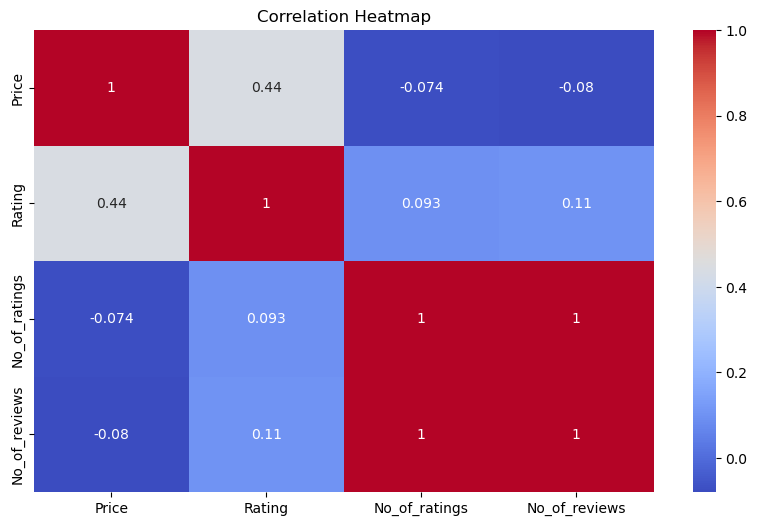

In [15]:
# Correlation Heatmap

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


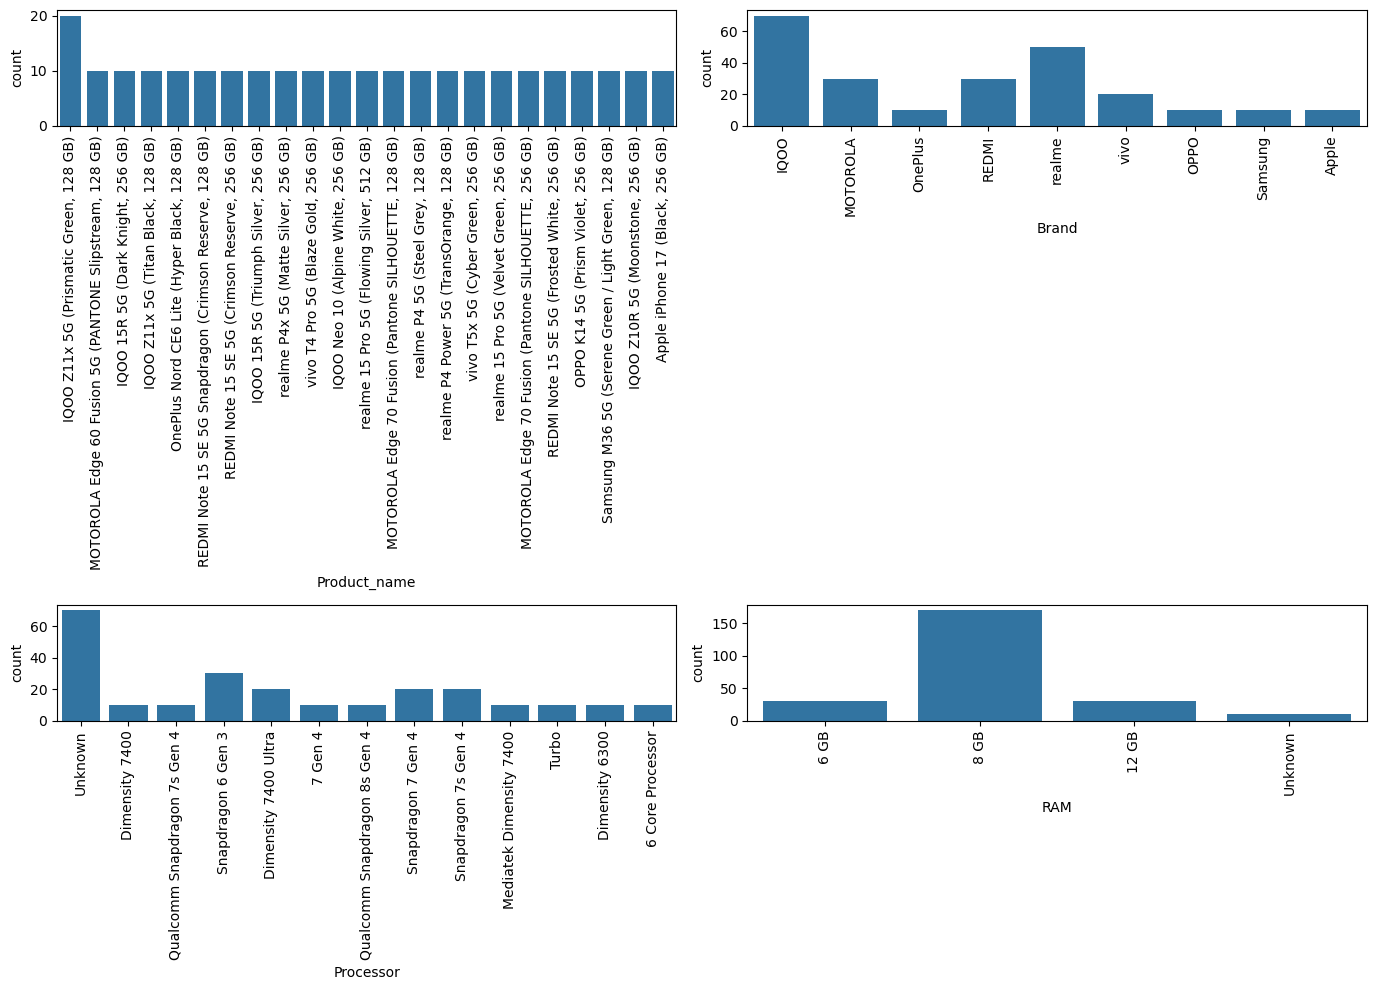

In [16]:
# Count Plots for Categorical Columns

feature = ['Product_name', 'Brand', 'Processor', 'RAM']

plt.figure(figsize=(14,10))

for p, q in enumerate(feature):
    plt.subplot(2,2,p+1)
    sns.countplot(x=q, data=df)
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


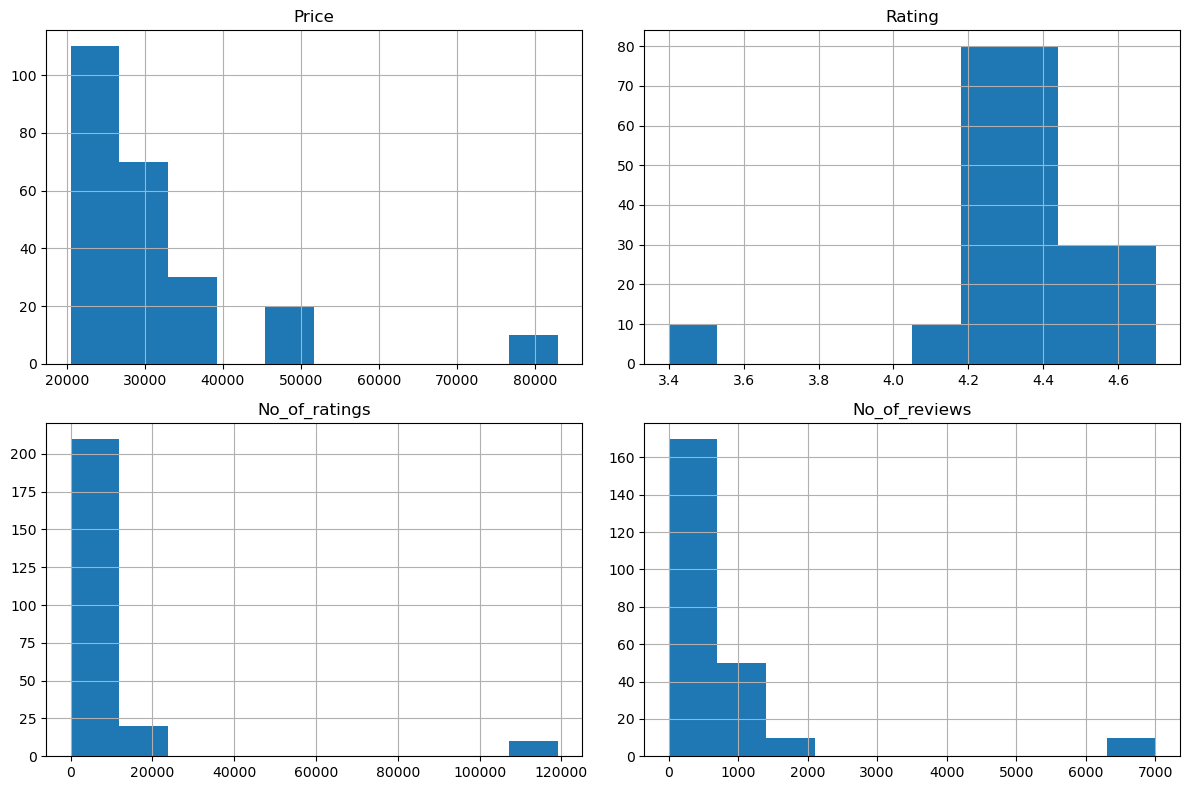

In [17]:
# Histograms for Numeric Columns

cols = ['Price', 'Rating', 'No_of_ratings', 'No_of_reviews']

df[cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()


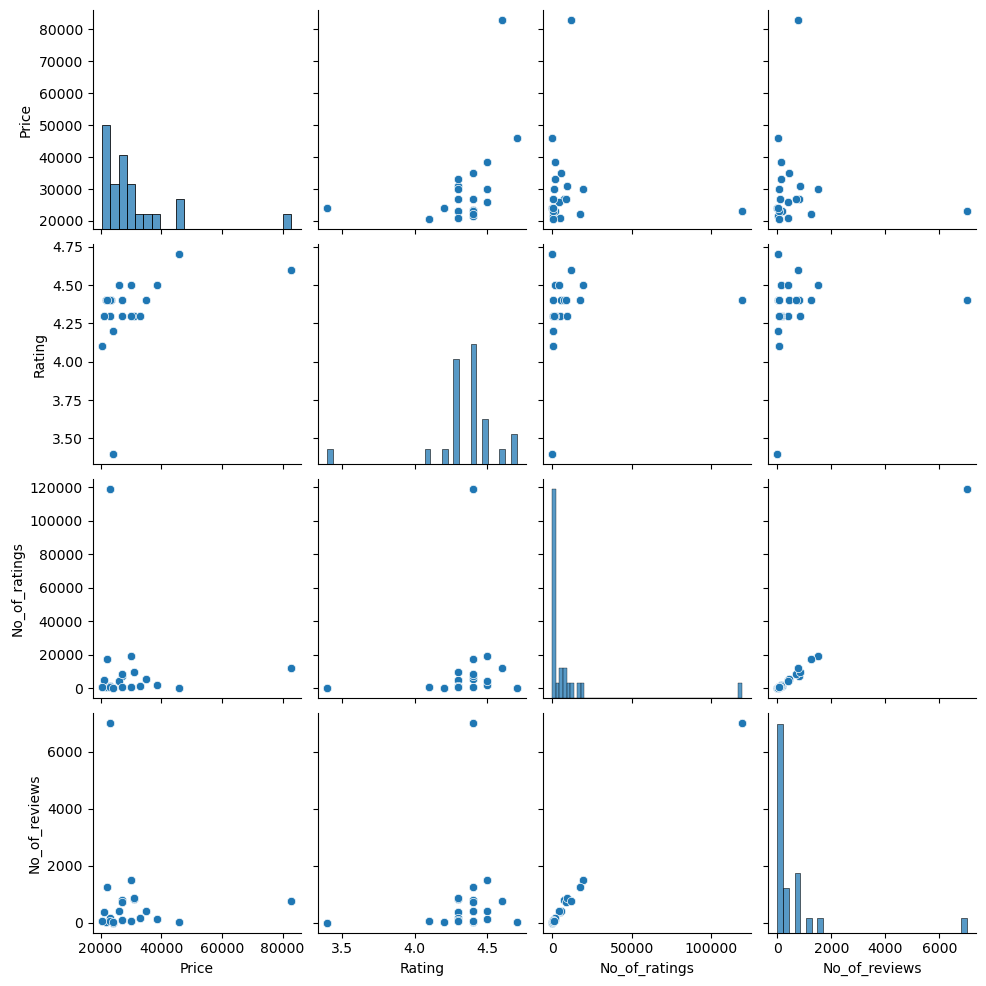

In [18]:
# Pairplot

sns.pairplot(df[['Price', 'Rating', 'No_of_ratings', 'No_of_reviews']])
plt.show()


In [19]:
# Final Cleaned Dataset Shape
print(df.shape)


(240, 12)


# Conclusion

In this notebook, we performed:

- Data Cleaning
- Missing Value Handling
- Duplicate Removal
- Exploratory Data Analysis (EDA)
- Data Visualization

The dataset is now cleaner and ready for Machine Learning or further analysis.
